# Kriging Accuracy Tests

Using modified versions of kriging.py.

In [250]:
from importlib import reload
try:
    reload(kriging_for_tests)
    from kriging_for_tests import Kriging
except:
    import kriging_for_tests
    reload(kriging_for_tests)
    from kriging_for_tests import Kriging

# try:
#     reload(kriging_for_tests2)
#     from kriging_for_tests2 import Kriging
# except:
#     import kriging_for_tests2
#     reload(kriging_for_tests2)
#     from kriging_for_tests2 import Kriging

import numpy as np
import matplotlib.pyplot as plt

import time

In [251]:
freqarr, freqstep = np.linspace(0,250,4096,retstep=True) # Based on number of frequency channels of the antenna
# minfreq = 30
# maxfreq = 200
# minfreqarg = int(minfreq/freqstep)
# maxfreqarg = int(maxfreq/freqstep)
print(freqstep)
print(freqarr[2000:2002])
freq = 100 # MHz
freq_index = int(freq/freqstep)
print(freq_index)

0.06105006105006105
[122.1001221  122.16117216]
1638


In [252]:
# Load in the data
year = '2021'
instrument = '100MHz'
channel = 'NS'

datadir = '../test_data/'+year+'/'+instrument+'/'+channel+'/'

save_mask = np.load(datadir+'shortdata_'+year+'_'+instrument+'_'+channel+'_mask.npy')
dat=np.load(datadir+'shortdata_meas_'+year+'_'+instrument+'_'+channel+'.npy')[save_mask]
lst=np.load(datadir+'shortlst_'+year+'_'+instrument+'_'+channel+'.npy')[save_mask]
t=np.load(datadir+'shortsystime_'+year+'_'+instrument+'_'+channel+'.npy')[save_mask]
t_ant = np.load(datadir+'antsystime_'+year+'_'+instrument+'_'+channel+'.npy')

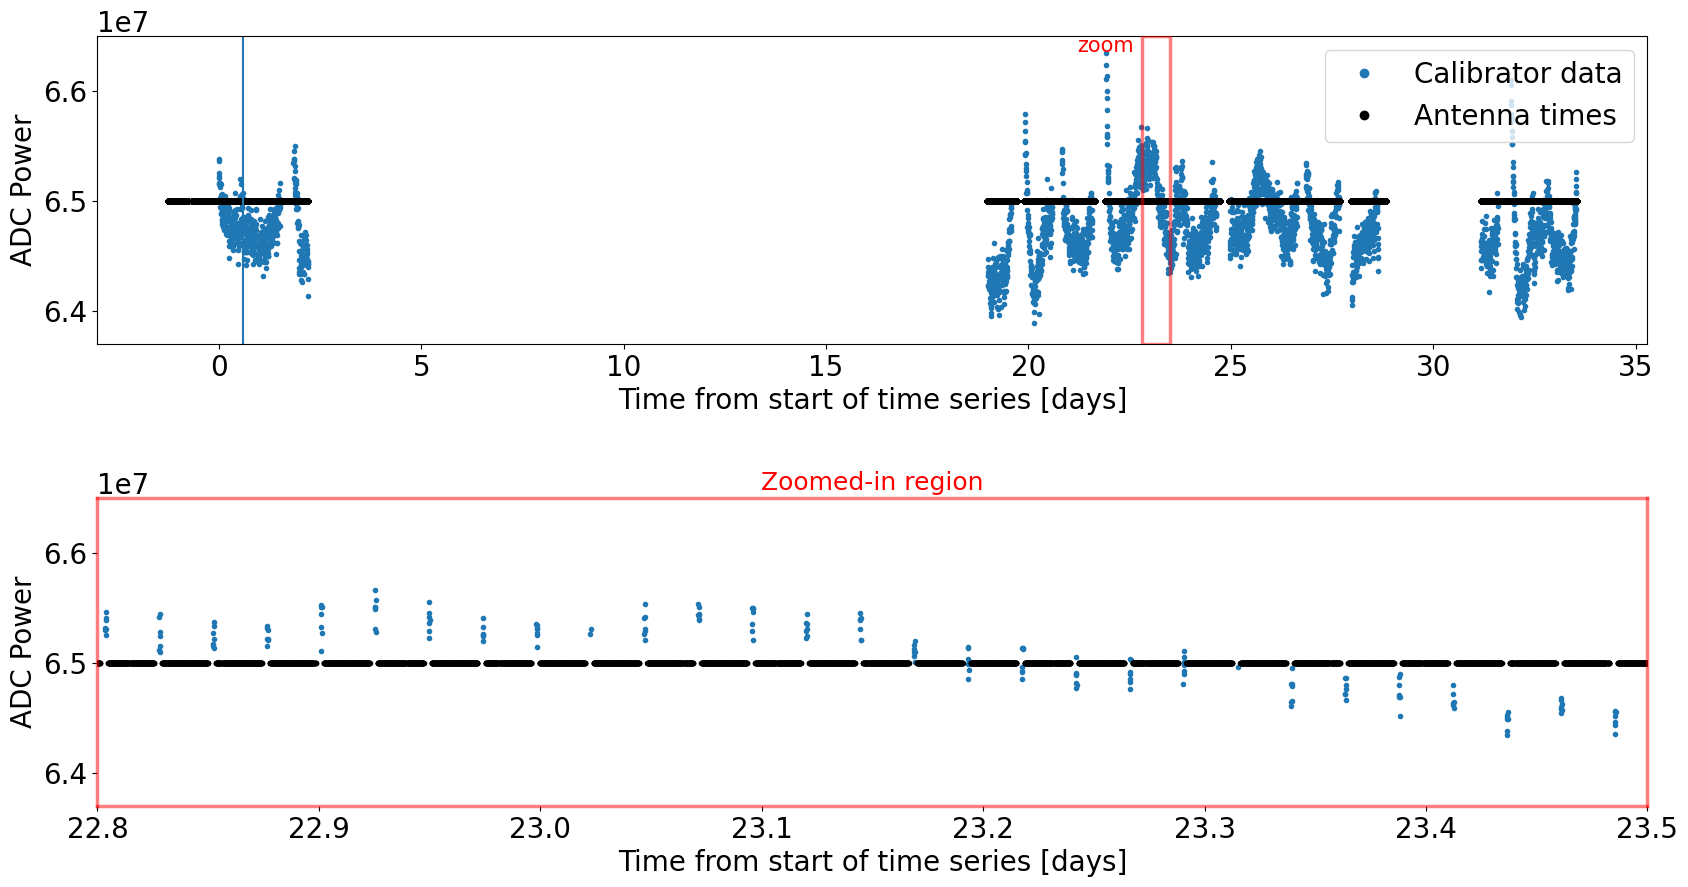

In [253]:
# Optional: select a subset of the data (mostly for testing)
# tmax=1.6374e9
# tmin=1.6365e9
# tmax=1.636e9
tmax=np.inf
tmin=0

mask=(t>tmin)&(t<tmax)
tt=t[mask]
dd=dat[mask,:]

ant_mask = (t_ant>tmin)&(t_ant<tmax)
tt_ant = t_ant[ant_mask]

# Pick a freq_index to plot (the fit is done for all frequencies)
plt.rcParams.update({'font.size': 20})
fig, ax = plt.subplots(nrows=2,ncols=1,figsize=(20,10))
plt.subplots_adjust(hspace=0.5)

# Main plot
ax[0].plot((tt-tt[0])/(3600*24),dd[:,freq_index],'.',label='Calibrator data')
ax[0].plot((tt_ant-tt[0])/(3600*24),[6.5e7 for ti in tt_ant],'.',color='black',label='Antenna times')
# plt.title('Short Calibrator Data and Antenna Times To Interpolate To\nFrequency Channel = '+str(freq)+'MHz')
# plt.xlim(left=-40,right=60)
# plt.xlim(left=450)
ax[0].set_xlabel('Time from start of time series [days]')
ax[0].set_ylabel('ADC Power')
ax[0].set_ylim(6.37e7,6.65e7)
ax[0].legend(loc='upper right',markerscale=2)

# Zoomed plot
zoom_start = 22.8 # days
zoom_end = 23.5
zoom_ylim = (6.37e7,6.65e7)
ax[1].plot((tt-tt[0])/(3600*24),dd[:,freq_index],'.',label='Calibrator data')
ax[1].plot((tt_ant-tt[0])/(3600*24),[6.5e7 for ti in tt_ant],'.',color='black',label='Antenna times')
ax[1].set_xlim(zoom_start, zoom_end)
ax[1].set_ylim(*zoom_ylim)
# ax[2].set_yticks(custom_tick_positions)
# ax[2].set_yticklabels(custom_tick_labels)
# ax[2].set_xlabel('UNIX Timestamp [s]')
ax[1].set_xlabel('Time from start of time series [days]')
ax[1].set_ylabel('ADC Power')
ax[1].set_title("Zoomed-in region",fontsize=18,color='red')

from matplotlib.patches import Patch, Rectangle
# Add rectangle to ax2 to indicate zoomed-in area
highlight_rect = Rectangle(
    (zoom_start, zoom_ylim[0]),                    # (x0, y0)
    width=zoom_end - zoom_start,                   # width in datetime
    height=zoom_ylim[1]-0.01 - zoom_ylim[0],            # height
    linewidth=2.5,
    edgecolor='red',
    facecolor='none',
    alpha=0.5,
    linestyle='-',
    zorder=100 # in front of everything else
)
ax[0].add_patch(highlight_rect)

# Match zoomed-in subplot outline to box color
for spine in ax[1].spines.values():
    spine.set_edgecolor((1, 0, 0, 0.5))
    spine.set_linewidth(2.5)
    spine

# Coordinates for top-right corner of the rectangle
label_x = zoom_start-0.2
label_y = zoom_ylim[1]

# Add "zoom" text inside the rectangle
ax[0].text(
    label_x, label_y, 'zoom',
    color='red',
    fontsize=15,
    ha='right', va='top',
    zorder=101  # ensure it sits above the rectangle
)

ax[0].vlines(x=(tt_ant[20000]-tt[0])/(3600*24),ymin=6.3e7,ymax=6.7e7)
# plt.savefig('PreInterp-2021-100-NS-100MHzchan-short-zoombox.jpg',bbox_inches='tight',dpi=300)
plt.show()

In [108]:
'''Randomly get rid of some input data'''
rn = np.random.choice(a=[0,1],size=len(t),p=[0.2,0.8]) # randomly chooses which points to mask from the calibrator data
test_mask = rn == 1
print(t[~test_mask])
# test_mask = ((t-t[0])>=20.2*3600*24)&((t-t[0])<=20.3*3600*24)
print(np.sum(test_mask))

[1.63501004e+09 1.63501004e+09 1.63501633e+09 1.63501636e+09
 1.63501842e+09 1.63502054e+09 1.63502264e+09 1.63502265e+09
 1.63502474e+09 1.63502475e+09 1.63502683e+09 1.63502895e+09
 1.63502896e+09 1.63503107e+09 1.63503527e+09 1.63503946e+09
 1.63503949e+09 1.63504159e+09 1.63504368e+09 1.63504787e+09
 1.63504999e+09 1.63505419e+09 1.63505629e+09 1.63505631e+09
 1.63505631e+09 1.63505839e+09 1.63506050e+09 1.63506260e+09
 1.63506472e+09 1.63506473e+09 1.63506682e+09 1.63506684e+09
 1.63506891e+09 1.63507102e+09 1.63507311e+09 1.63507314e+09
 1.63507734e+09 1.63507735e+09 1.63507944e+09 1.63508156e+09
 1.63508364e+09 1.63508573e+09 1.63508574e+09 1.63508576e+09
 1.63508995e+09 1.63509205e+09 1.63510046e+09 1.63510258e+09
 1.63510468e+09 1.63510468e+09 1.63510469e+09 1.63510677e+09
 1.63510678e+09 1.63510891e+09 1.63511100e+09 1.63511101e+09
 1.63511309e+09 1.63511310e+09 1.63511312e+09 1.63511518e+09
 1.63511731e+09 1.63511731e+09 1.63511939e+09 1.63511940e+09
 1.63511942e+09 1.635121

In [344]:
# Step 1: Initialize Kriging class
# You can actually pass tmax and tmin to the Kriging object and it'll select for you
'''Make the kriging algo predict the masked points'''
krig_object = Kriging(systime=t,data=dat,interp_times=t,tmax_mask=tmax,tmin_mask=tmin,
                      minfreq=100,maxfreq=100)

## Making plots

## Back to Kriging

In [345]:
# Step 2: Call the object to perform the Kriging
tstart = time.time()
krig_object(dt=5,dtmax=10*3600,acf_functype='quadpeak') # dt and dtmax in seconds
tend = time.time()
print('Time taken:',tend-tstart,'sec')

Verifying freq args are the same within kriging object: min 1638 , max 1638
100.0 MHz channel done
Time taken: 2.288120746612549 sec


In [346]:
slct = 0
rslt = krig_object.interp_data[slct]
# print(rslt)
err = krig_object.interp_std[slct]
avgd_time = krig_object.save_avgd_time[slct]
avgd_data = krig_object.save_avgd_data[slct]
avgd_data_std = krig_object.save_avgd_data_std[slct]
test_mask = krig_object.test_mask
print((avgd_time[~test_mask]-t[0])/(3600*24))
print(rslt)
# print(test_mask)
# print((avgd_time[test_mask]-tt[0])/(3600*24))
# Saving some testing data
# rslt_nonavgd = krig_object.interp_data[slct]
# err_nonavgd = krig_object.interp_std[slct]
# plt.plot(tt_ant,(rslt-rslt_nonavgd)/rslt *100)
# plt.show()

[ 0.04891522  0.38975483  0.4871379   0.60890366  0.73059255  0.8036677
  0.90105112  0.97405115  1.14450854  1.36365588  1.92356776  1.97226213
  1.99660489  2.02095334  2.09402781 18.98915848 19.06219537 19.08654029
 19.20827192 19.40307065 19.57345353 19.93106075 20.19886536 20.3205943
 20.3693226  20.83185117 20.8805449  20.92923564 20.9536165  21.00230738
 21.17269263 21.34322185 21.44052805 21.53791049 22.31682396 22.43858976
 22.46289785 22.48724291 22.7063569  22.80373701 22.87681055 23.07157616
 23.12026496 23.53410673 23.63149095 24.26447761 24.36186115 24.48362723
 24.97353297 25.07091519 25.09526076 25.11960932 25.14395349 25.29002679
 25.3143722  25.36306165 25.43613707 25.60652153 25.72828783 25.75259778
 25.89867119 25.92305333 26.02043536 26.21520005 26.41003689 26.53165363
 27.01857327 27.04295604 27.26206487 27.45683258 27.55421565 27.62725225
 28.10697784 28.18001413 28.25305242 28.30174318 28.4721612  28.5208536
 31.17457381 31.19895367 31.24764494 31.34502972 31.58

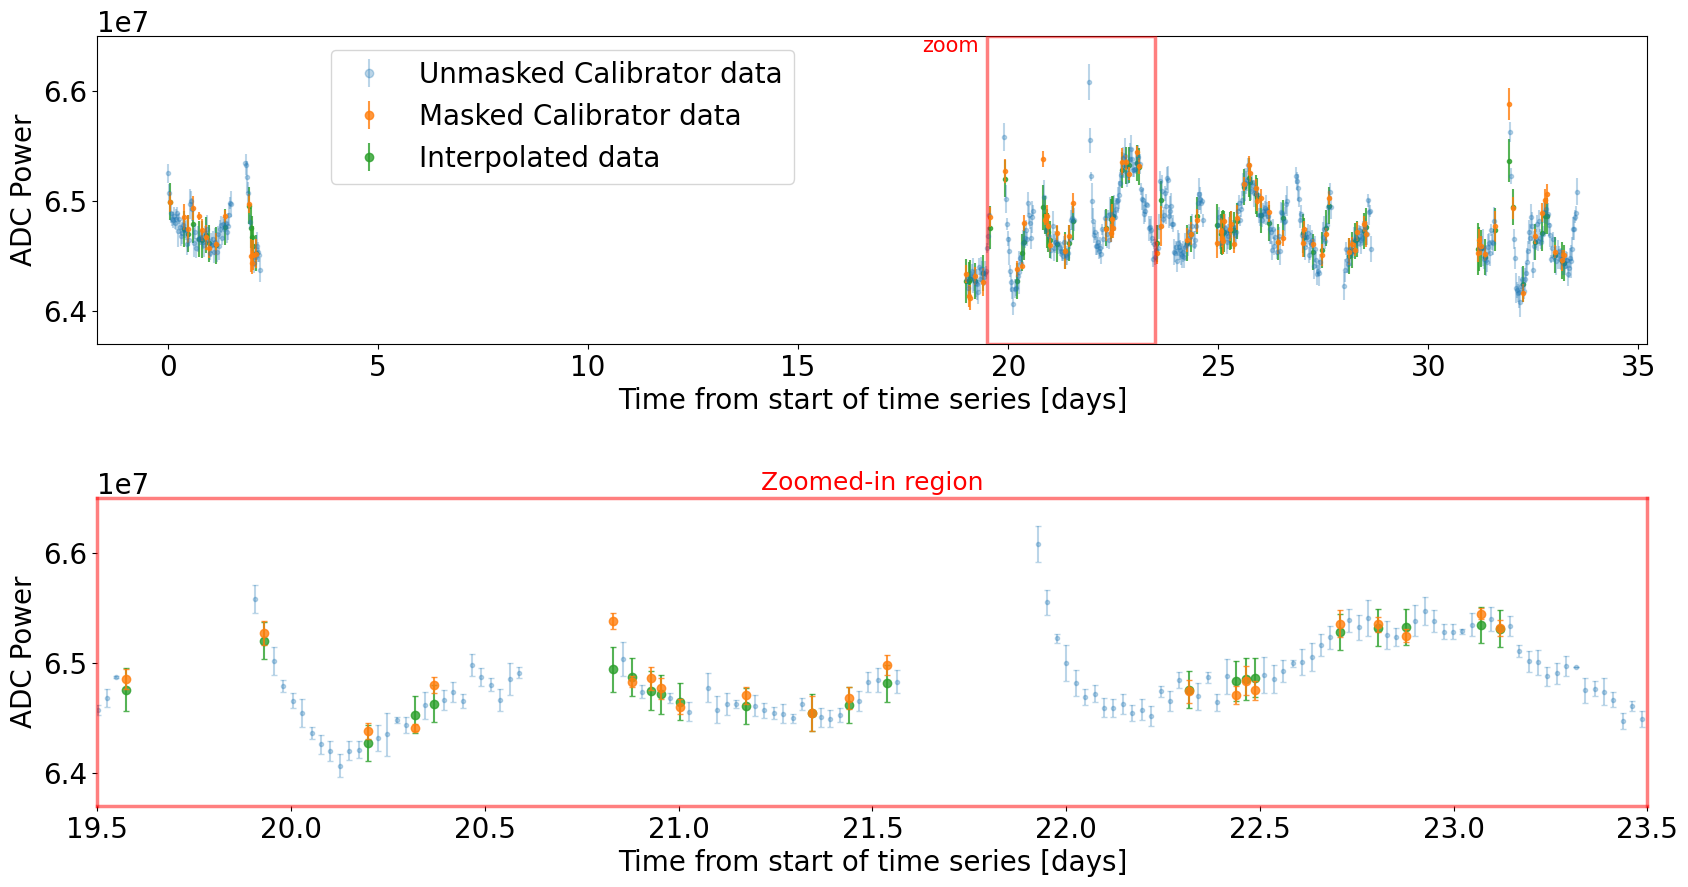

In [347]:
# Optional: select a subset of the data (mostly for testing)
# tmax=1.6374e9
# tmin=1.6365e9
# tmax=1.636e9
tmax=np.inf
tmin=0

mask=(t>tmin)&(t<tmax)
tt=t[mask]
dd=dat[mask,:]

ant_mask = (t_ant>tmin)&(t_ant<tmax)
tt_ant = t_ant[ant_mask]

# Pick a freq_index to plot (the fit is done for all frequencies)
plt.rcParams.update({'font.size': 20})
fig, ax = plt.subplots(nrows=2,ncols=1,figsize=(20,10))
plt.subplots_adjust(hspace=0.5)

# Main plot
ax[0].errorbar(x=(avgd_time[test_mask]-tt[0])/(3600*24),y=avgd_data[test_mask],yerr=avgd_data_std[test_mask],marker='.',ls='none',label='Unmasked Calibrator data',alpha=0.3)
ax[0].errorbar(x=(avgd_time[~test_mask]-tt[0])/(3600*24),y=avgd_data[~test_mask],yerr=avgd_data_std[~test_mask],marker='.',ls='none',label='Masked Calibrator data',alpha=0.8)
ax[0].errorbar(x=(avgd_time[~test_mask]-tt[0])/(3600*24),y=rslt,yerr=err,marker='.',label='Interpolated data',ls='none',zorder=1,alpha=0.8)
# ax[0].plot((tt_ant-tt[0])/(3600*24),[6.5e7 for ti in tt_ant],'.',color='black',label='Antenna times')
# plt.title('Short Calibrator Data and Antenna Times To Interpolate To\nFrequency Channel = '+str(freq)+'MHz')
# plt.xlim(left=-40,right=60)
# plt.xlim(left=450)
ax[0].set_xlabel('Time from start of time series [days]')
ax[0].set_ylabel('ADC Power')
ax[0].set_ylim(6.37e7,6.65e7)
ax[0].legend(loc='upper center',bbox_to_anchor=(0.3, 1.0),markerscale=2)

# Zoomed plot
zoom_start = 19.5 # days
zoom_end = 23.5
zoom_ylim = (6.37e7,6.65e7)
ax[1].errorbar(x=(avgd_time[test_mask]-tt[0])/(3600*24),y=avgd_data[test_mask],yerr=avgd_data_std[test_mask],marker='.',ls='none',label='Unmasked Calibrator data',alpha=0.3,capsize=2)
ax[1].errorbar(x=(avgd_time[~test_mask]-tt[0])/(3600*24),y=avgd_data[~test_mask],yerr=avgd_data_std[~test_mask],marker='o',ls='none',label='Masked Calibrator data',alpha=0.8,capsize=2)
ax[1].errorbar(x=(avgd_time[~test_mask]-tt[0])/(3600*24),y=rslt,yerr=err,marker='o',label='Interpolated data',ls='none',zorder=1,alpha=0.8,capsize=2)
ax[1].set_xlim(zoom_start, zoom_end)
ax[1].set_ylim(*zoom_ylim)
# ax[2].set_yticks(custom_tick_positions)
# ax[2].set_yticklabels(custom_tick_labels)
# ax[2].set_xlabel('UNIX Timestamp [s]')
ax[1].set_xlabel('Time from start of time series [days]')
ax[1].set_ylabel('ADC Power')
ax[1].set_title("Zoomed-in region",fontsize=18,color='red')

from matplotlib.patches import Patch, Rectangle
# Add rectangle to ax2 to indicate zoomed-in area
highlight_rect = Rectangle(
    (zoom_start, zoom_ylim[0]),                    # (x0, y0)
    width=zoom_end - zoom_start,                   # width in datetime
    height=zoom_ylim[1]-0.01 - zoom_ylim[0],            # height
    linewidth=2.5,
    edgecolor='red',
    facecolor='none',
    alpha=0.5,
    linestyle='-',
    zorder=100 # in front of everything else
)
ax[0].add_patch(highlight_rect)

# Match zoomed-in subplot outline to box color
for spine in ax[1].spines.values():
    spine.set_edgecolor((1, 0, 0, 0.5))
    spine.set_linewidth(2.5)
    spine

# Coordinates for top-right corner of the rectangle
label_x = zoom_start-0.2
label_y = zoom_ylim[1]

# Add "zoom" text inside the rectangle
ax[0].text(
    label_x, label_y, 'zoom',
    color='red',
    fontsize=15,
    ha='right', va='top',
    zorder=101  # ensure it sits above the rectangle
)

# ax[0].vlines(x=(tt_ant[20000]-tt[0])/(3600*24),ymin=6.3e7,ymax=6.7e7)
# plt.savefig('TestInterpShortMasked-2021-100-NS-100MHzchan-short-zoombox.jpg',bbox_inches='tight',dpi=300)
# plt.savefig('TestInterpShortMaskedData10hChunk-2021-100-NS-100MHzchan-short-zoombox.jpg',bbox_inches='tight',dpi=300)
plt.show()

[ 0.73059255 20.83185117 31.92932463]
[64859682.         65381228.         65878802.57142857] +- [ 37815.08321896  71859.71011035 141769.33544606]
[64650859.17359427 64939185.05286924 65365293.02912165] +- [165345.00288452 201074.17317937 197820.03405428]
96.7741935483871


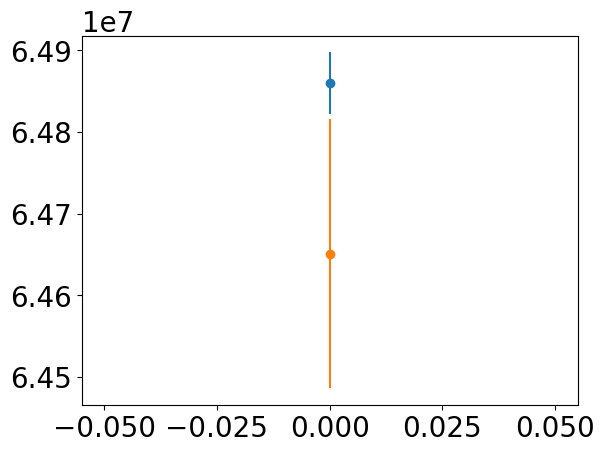

In [350]:
# Check if all values match within uncertainty
ax[0].errorbar(x=(avgd_time[~test_mask]-tt[0])/(3600*24),y=avgd_data[~test_mask],yerr=avgd_data_std[~test_mask],marker='.',ls='none',label='Masked Calibrator data',alpha=0.8)
ax[0].errorbar(x=(avgd_time[~test_mask]-tt[0])/(3600*24),y=rslt,yerr=err,marker='.',label='Interpolated data',ls='none',zorder=1,alpha=0.8)
matches = np.abs(avgd_data[~test_mask] - rslt) <= 1*(avgd_data_std[~test_mask] + err)
all_match = np.all(matches)
non_matches = np.where(~matches)[0]
print((avgd_time[~test_mask]-tt[0])[non_matches]/(3600*24))
print(avgd_data[~test_mask][non_matches],'+-',avgd_data_std[~test_mask][non_matches])
print(rslt[non_matches],'+-',err[non_matches])
print(np.sum(matches)/len(rslt) * 100)
plt.errorbar(x=0,y=avgd_data[~test_mask][non_matches][0],yerr=avgd_data_std[~test_mask][non_matches][0],marker='o')
plt.errorbar(x=0,y=rslt[non_matches][0],yerr=err[non_matches][0],marker='o')
plt.show()

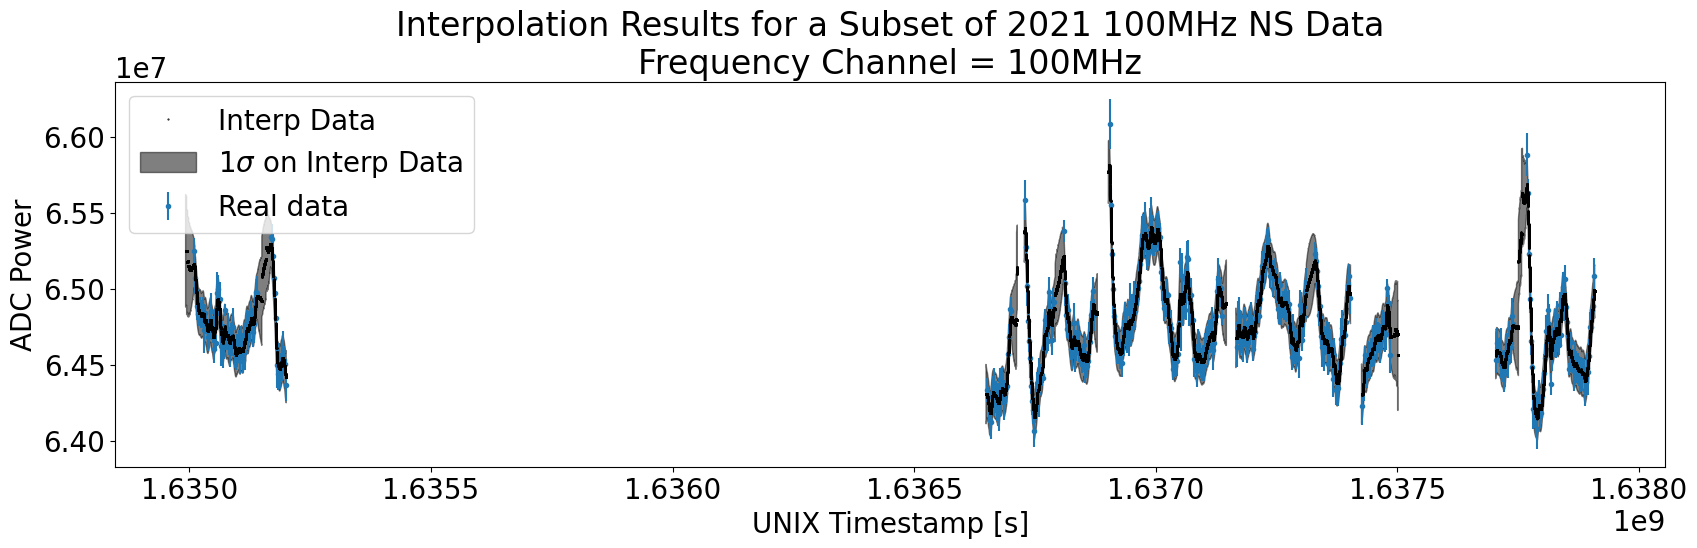

In [134]:
fig = plt.figure(figsize=(20,5))
plt.rcParams.update({'font.size': 20})

# Select frequency ------
freq = 100 # MHz
freq_index = int(freq/freqstep)
# -----------------------

# Plot the averaged data with error bars
x = tt_ant
y1 = (rslt-err)
y2 = (rslt+err)

gap_threshold = 60*60 # 1h gap threshold
mask = np.ediff1d(x, to_begin=0) > gap_threshold

x_masked = np.ma.masked_where(mask, x)
y1_masked = np.ma.masked_where(mask, y1)
y2_masked = np.ma.masked_where(mask, y2)

plt.errorbar(x=avgd_time,y=avgd_data,yerr=avgd_data_std,marker='.',label='Real data',ls='none',zorder=1)

# Plot the results of the interpolation at antenna times
plt.plot(tt_ant,rslt,'.',ms=1,label='Interp Data',color='k',zorder=2)
plt.fill_between(x_masked,y1_masked,y2_masked,alpha=0.5,color='k',zorder=0,label=r'1$\sigma$ on Interp Data')

# plt.ylim(bottom=7e7)
plt.xlabel('UNIX Timestamp [s]')
plt.ylabel('ADC Power')
plt.legend()
plt.title('Interpolation Results for a Subset of '+year+' '+instrument+' '+channel+' Data\nFrequency Channel = '+str(freq)+'MHz')
# plt.plot(tt_ant,[6.6e7 for ti in tt_ant],'.',color='red',label='Antenna times (interp times)')
# plt.xlim(left= 1.6365e9,right=1.6380e9)
# plt.ylim(top=6.9e7,bottom=6.4e7)
# plt.savefig('InterpRslt',dpi=300)
plt.show()

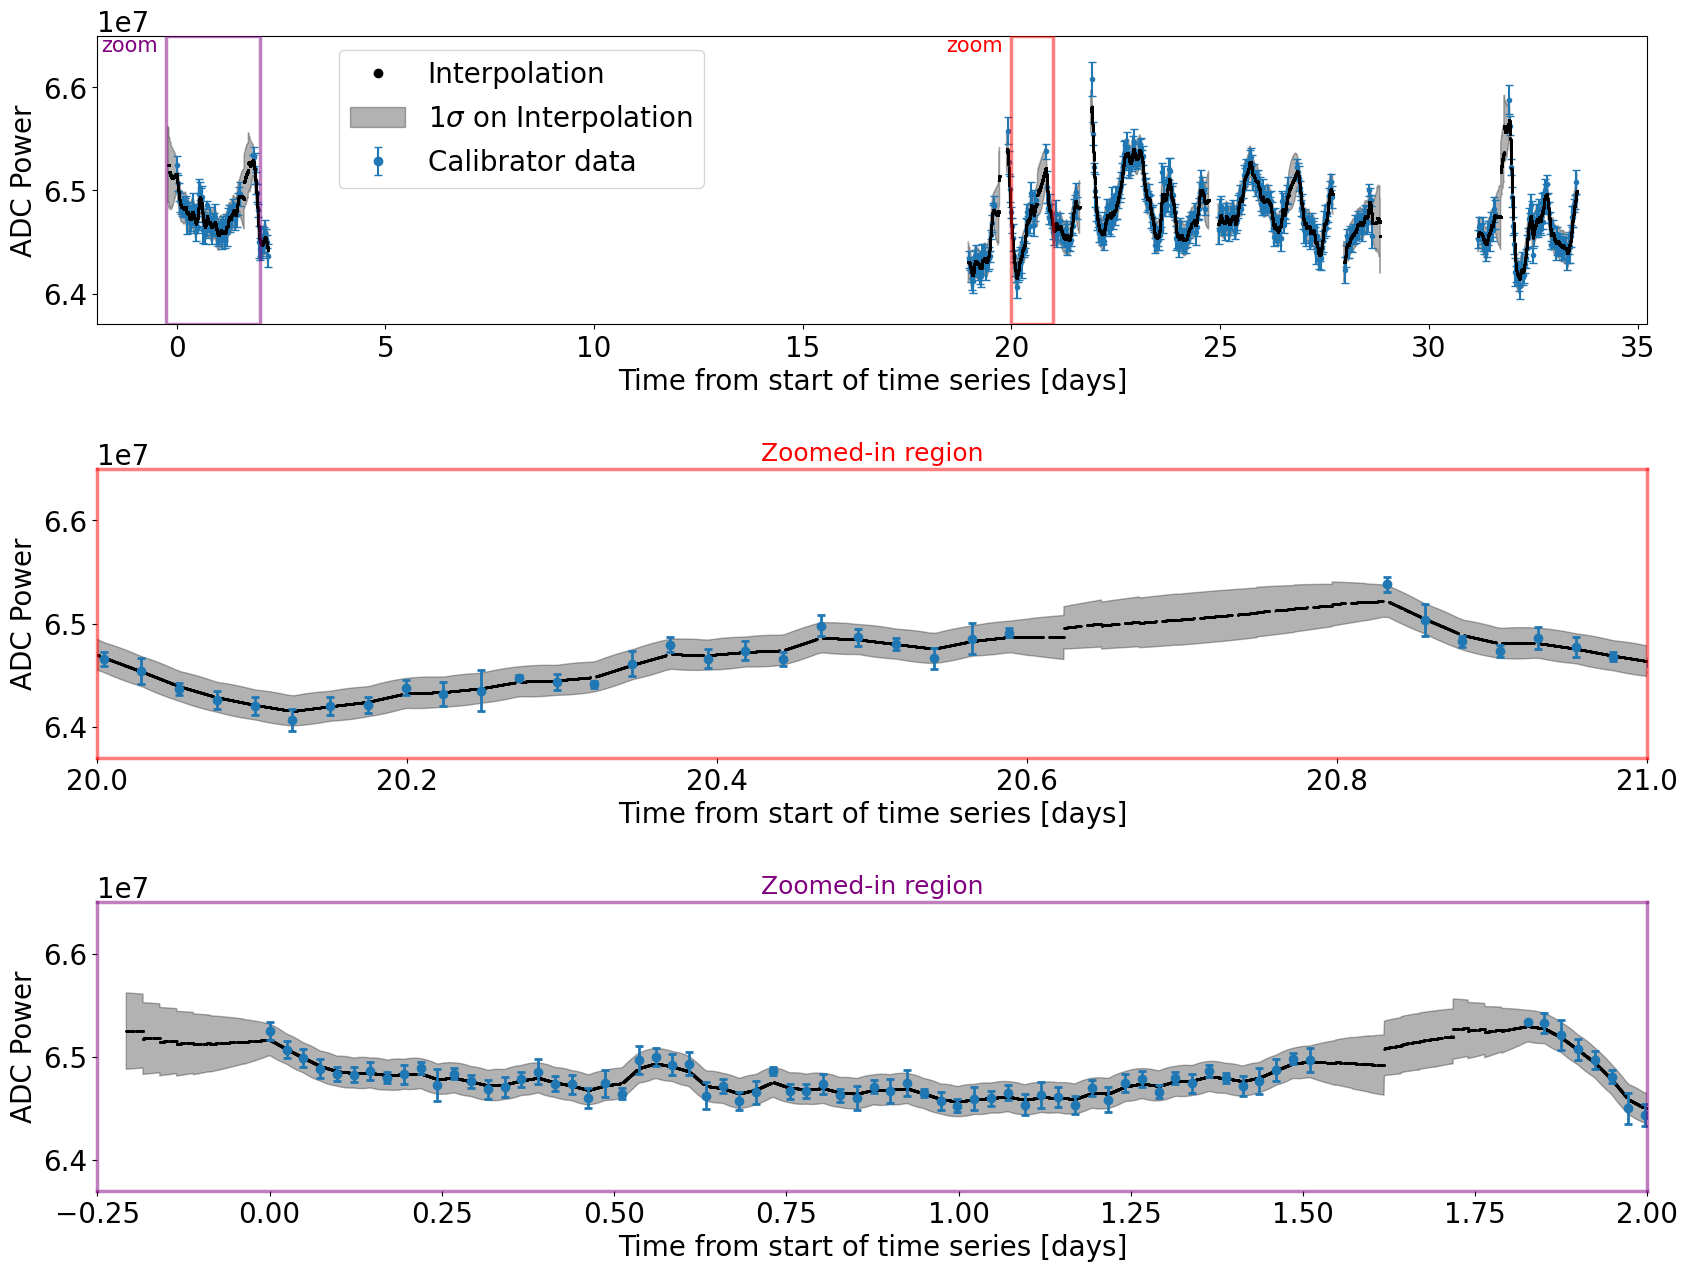

In [169]:
# Optional: select a subset of the data (mostly for testing)
from matplotlib.lines import Line2D
# Pick a freq_index to plot (the fit is done for all frequencies)
plt.rcParams.update({'font.size': 20})
fig, ax = plt.subplots(nrows=3,ncols=1,figsize=(20,15))
plt.subplots_adjust(hspace=0.5)

# Main plot
ax[0].plot((tt_ant-tt[0])/(3600*24),rslt,'.',ms=1,label='Interpolation',color='k',zorder=2)
ax[0].fill_between((x_masked-tt[0])/(3600*24),y1_masked,y2_masked,alpha=0.3,color='k',zorder=0,label=r'1$\sigma$ on Interpolation')
ax[0].errorbar(x=(avgd_time-tt[0])/(3600*24),y=avgd_data,yerr=avgd_data_std,marker='.',label='Calibrator data',ls='none',zorder=1,capsize=3)
# ax[0].plot((tt-tt[0])/(3600*24),dd[:,freq_index],'.',label='Calibrator data',zorder=0)
# ax[0].plot((tt_ant-tt[0])/(3600*24),[6.5e7 for ti in tt_ant],'.',color='black',label='Antenna times')
# plt.title('Short Calibrator Data and Antenna Times To Interpolate To\nFrequency Channel = '+str(freq)+'MHz')
# plt.xlim(left=-40,right=60)
# plt.xlim(left=450)
ax[0].set_xlabel('Time from start of time series [days]')
ax[0].set_ylabel('ADC Power')
ax[0].set_ylim(6.37e7,6.65e7)
handles, labels = ax[0].get_legend_handles_labels()
custom_index = labels.index('Interpolation')
handles[custom_index] = Line2D(
    [0], [0], marker='.', color='k', linestyle='None',
    markersize=6, label='Interpolation'
)
ax[0].legend(handles=handles, labels=labels,markerscale=2,bbox_to_anchor=(0.4, 1.0))

# Zoomed plot
zoom_start = 20 # days
zoom_end = 21
zoom_ylim = (6.37e7,6.65e7)
ax[1].plot((tt_ant-tt[0])/(3600*24),rslt,'.',ms=1,label='Interpolation',color='k',zorder=1)
ax[1].fill_between((x_masked-tt[0])/(3600*24),y1_masked,y2_masked,alpha=0.3,color='k',zorder=0,label=r'1$\sigma$ on Interpolation')
ax[1].errorbar(x=(avgd_time-tt[0])/(3600*24),y=avgd_data,yerr=avgd_data_std,marker='o',label='Calibrator data',ls='none',zorder=2,capsize=3,elinewidth=2,capthick=2)
# ax[1].plot((tt-tt[0])/(3600*24),dd[:,freq_index],'.',label='Calibrator data')

ax[1].set_xlim(zoom_start, zoom_end)
ax[1].set_ylim(*zoom_ylim)
# ax[2].set_yticks(custom_tick_positions)
# ax[2].set_yticklabels(custom_tick_labels)
# ax[2].set_xlabel('UNIX Timestamp [s]')
ax[1].set_xlabel('Time from start of time series [days]')
ax[1].set_ylabel('ADC Power')
ax[1].set_title("Zoomed-in region",fontsize=18,color='red')

from matplotlib.patches import Patch, Rectangle
# Add rectangle to ax2 to indicate zoomed-in area
highlight_rect = Rectangle(
    (zoom_start, zoom_ylim[0]),                    # (x0, y0)
    width=zoom_end - zoom_start,                   # width in datetime
    height=zoom_ylim[1]-0.01 - zoom_ylim[0],            # height
    linewidth=2.5,
    edgecolor='red',
    facecolor='none',
    alpha=0.5,
    linestyle='-',
    zorder=100 # in front of everything else
)
ax[0].add_patch(highlight_rect)

# Match zoomed-in subplot outline to box color
for spine in ax[1].spines.values():
    spine.set_edgecolor((1, 0, 0, 0.5))
    spine.set_linewidth(2.5)
    spine

# Coordinates for top-right corner of the rectangle
label_x = zoom_start-0.2
label_y = zoom_ylim[1]

# Add "zoom" text inside the rectangle
ax[0].text(
    label_x, label_y, 'zoom',
    color='red',
    fontsize=15,
    ha='right', va='top',
    zorder=101  # ensure it sits above the rectangle
)

# Zoomed plot 2
zoom_start = -0.25 # days
zoom_end = 2
zoom_ylim = (6.37e7,6.65e7)
ax[2].plot((tt_ant-tt[0])/(3600*24),rslt,'.',ms=1,label='Interpolation',color='k',zorder=1)
ax[2].fill_between((x_masked-tt[0])/(3600*24),y1_masked,y2_masked,alpha=0.3,color='k',zorder=0,label=r'1$\sigma$ on Interpolation')
ax[2].errorbar(x=(avgd_time-tt[0])/(3600*24),y=avgd_data,yerr=avgd_data_std,marker='o',label='Calibrator data',ls='none',zorder=2,capsize=3,elinewidth=2,capthick=2)
# ax[1].plot((tt-tt[0])/(3600*24),dd[:,freq_index],'.',label='Calibrator data')

ax[2].set_xlim(zoom_start, zoom_end)
ax[2].set_ylim(*zoom_ylim)
# ax[2].set_yticks(custom_tick_positions)
# ax[2].set_yticklabels(custom_tick_labels)
# ax[2].set_xlabel('UNIX Timestamp [s]')
ax[2].set_xlabel('Time from start of time series [days]')
ax[2].set_ylabel('ADC Power')
ax[2].set_title("Zoomed-in region",fontsize=18,color='purple')

# Add rectangle to ax2 to indicate zoomed-in area
highlight_rect = Rectangle(
    (zoom_start, zoom_ylim[0]),                    # (x0, y0)
    width=zoom_end - zoom_start,                   # width in datetime
    height=zoom_ylim[1]-0.01 - zoom_ylim[0],            # height
    linewidth=2.5,
    edgecolor='purple',
    facecolor='none',
    alpha=0.5,
    linestyle='-',
    zorder=100 # in front of everything else
)
ax[0].add_patch(highlight_rect)

# Match zoomed-in subplot outline to box color
for spine in ax[2].spines.values():
    spine.set_edgecolor((0.5, 0, 0.5, 0.5))
    spine.set_linewidth(2.5)
    spine

# Coordinates for top-right corner of the rectangle
label_x = zoom_start-0.2
label_y = zoom_ylim[1]

# Add "zoom" text inside the rectangle
ax[0].text(
    label_x, label_y, 'zoom',
    color='purple',
    fontsize=15,
    ha='right', va='top',
    zorder=101  # ensure it sits above the rectangle
)


plt.savefig('PostInterp-2021-100-NS-100MHzchan-short-TWOzoombox-AVGDATA.jpg',bbox_inches='tight',dpi=300)
plt.show()